In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
titanic = sns.load_dataset("titanic")

In [4]:
titanic.head()
# # titanic.describe6
# # titanic.info()
# titanic.isnull().sum()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
features = ["pclass","sex","age","fare","embarked","class"]
target = ["survived"]

In [6]:
# missing data 
from sklearn.impute import SimpleImputer
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]]) 


In [7]:
titanic[["age"]].head()

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [8]:
imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [9]:
titanic[["embarked"]].head()

,embarked
0,S
1,C
2,S
3,S
4,S


In [10]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
# encode 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])
titanic["class"] = le.fit_transform(titanic["class"])

In [12]:
x = titanic[features]
y = titanic[target]

In [13]:
# train data
x_train,x_test,y_train,y_test  = train_test_split(
    x,y,test_size = 0.2 , random_state=42
)

In [14]:
x_test.head()

,pclass,sex,age,fare,embarked,class
709,3,1,28.0,15.2458,0,2
439,2,1,31.0,10.5000,2,1
840,3,1,20.0,7.9250,2,2
720,2,0,6.0,33.0000,2,1
39,3,0,14.0,11.2417,0,2


In [15]:
# Drcision Tree Model - no Pruning

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred))

accuracy 0.7653631284916201


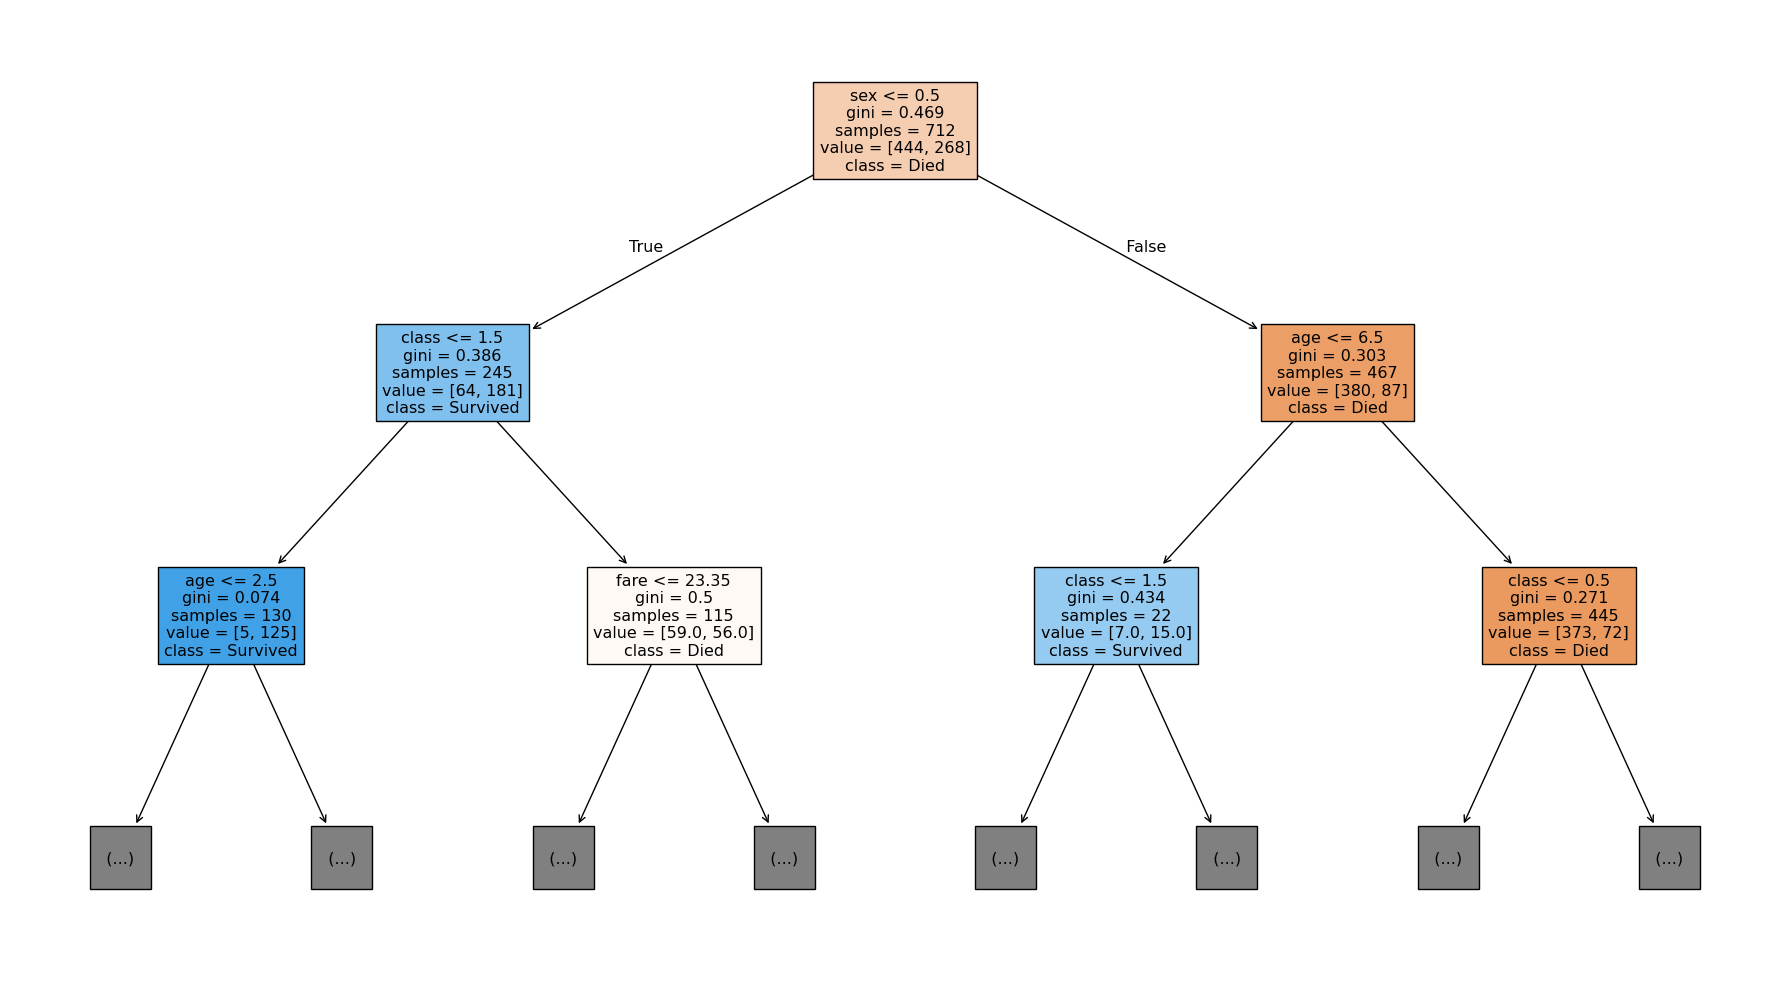

In [17]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["Died","Survived"],
    filled = True,
    max_depth=2
)
plt.tight_layout()
plt.show()

for depth = 2 , accuracy = 0.7653631284916201
for depth = 3 , accuracy = 0.7988826815642458
for depth = 4 , accuracy = 0.7988826815642458
for depth = 5 , accuracy = 0.7988826815642458
for depth = 6 , accuracy = 0.7988826815642458
for depth = 7 , accuracy = 0.7988826815642458
for depth = 8 , accuracy = 0.7932960893854749
for depth = 9 , accuracy = 0.7877094972067039
for depth = 10 , accuracy = 0.7932960893854749


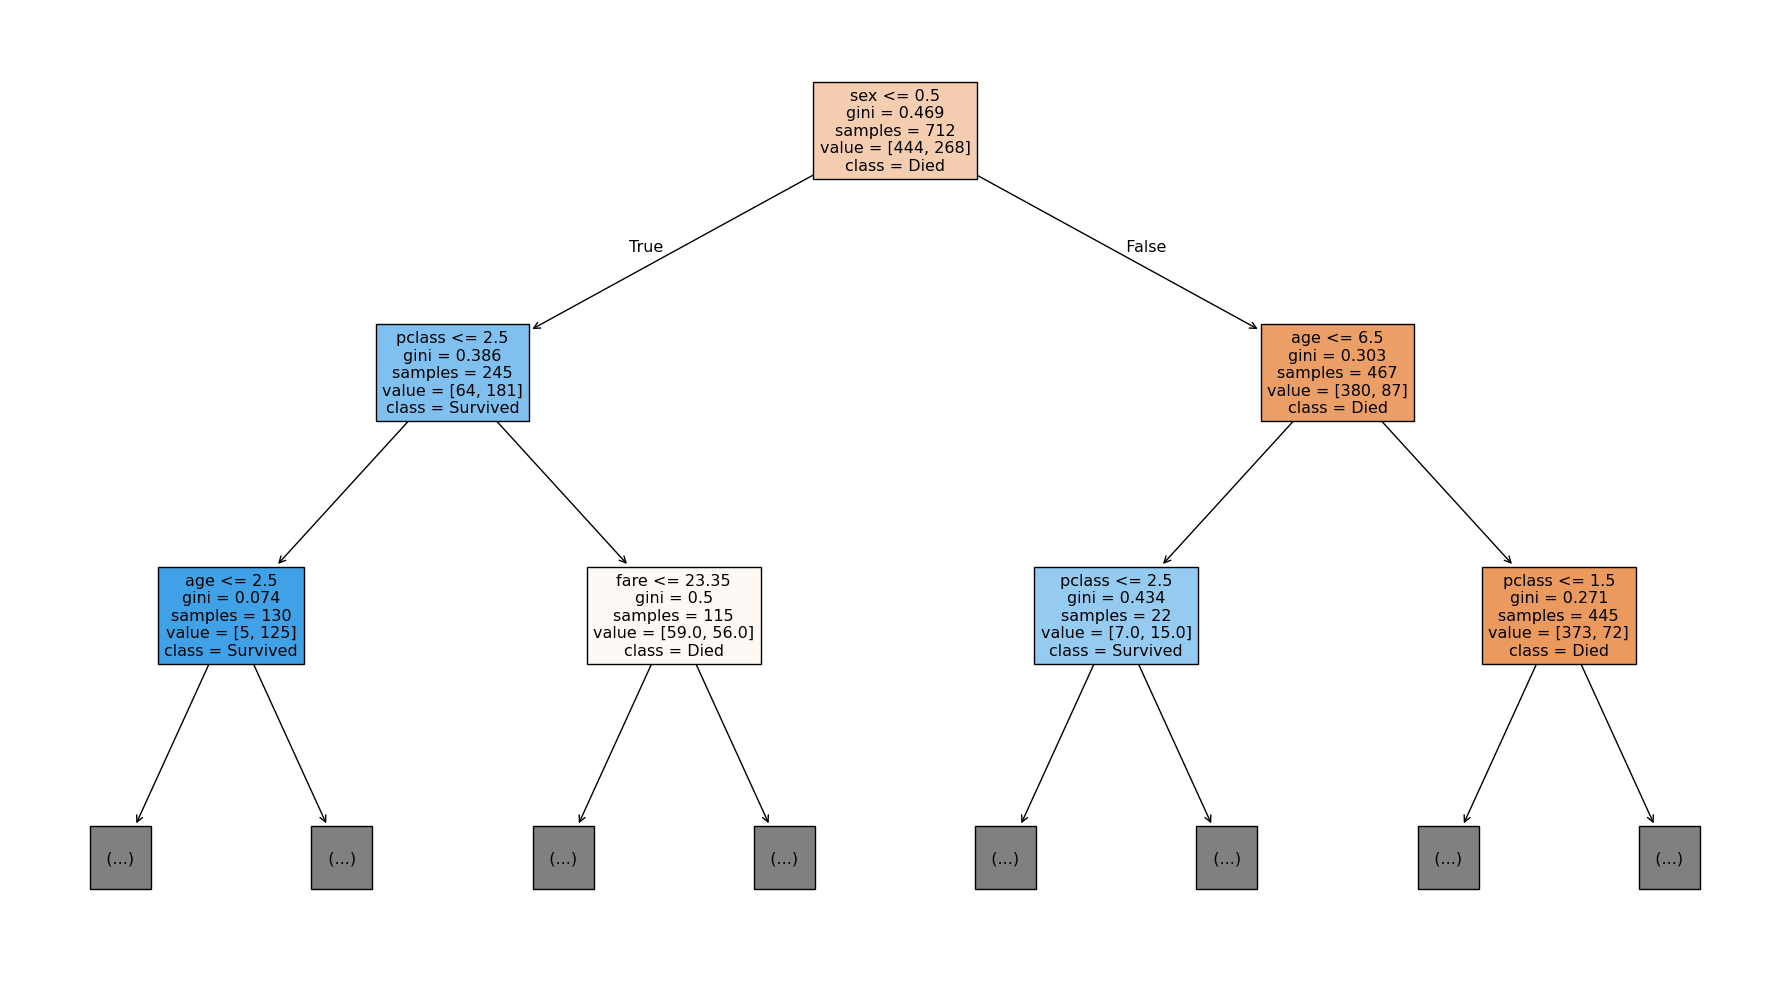

In [18]:
# pre-pruning implmentation

max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    acc = model.score(x_test,y_test)
    print(f"for depth = {depth} , accuracy = {acc}")

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["Died","Survived"],
    filled = True,
    max_depth=2
)
plt.tight_layout()
plt.show()

In [19]:
# pre-pruning implmentation

splits = [5,10,15,20,25,30]

for split in splits:
    model = DecisionTreeClassifier(max_depth=4 , min_samples_split=split)
    model.fit(x_train,y_train)
    acc = model.score(x_test,y_test)
    print(f"sample split = {split} , accuracy = {acc}")

sample split = 5 , accuracy = 0.7988826815642458
sample split = 10 , accuracy = 0.7988826815642458
sample split = 15 , accuracy = 0.7988826815642458
sample split = 20 , accuracy = 0.7988826815642458
sample split = 25 , accuracy = 0.7932960893854749
sample split = 30 , accuracy = 0.7932960893854749


In [20]:
# Decision Tree With Post - Pruning

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:

path = full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alp = path.ccp_alphas
print(ccp_alp)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.94231048e-04 8.99610781e-04 9.24769963e-04
 9.36329588e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.36329588e-04 9.88347898e-04 1.00253471e-03 1.05337079e-03
 1.07400895e-03 1.08038029e-03 1.11865144e-03 1.12359551e-03
 1.13139825e-03 1.18841832e-03 1.22566125e-03 1.22893258e-03
 1.22893258e-03 1.24361593e-03 1.24843945e-03 1.27565833e-03
 1.30996111e-03 1.33761370e-03 1.37044603e-03 1.47927070e-03
 1.51142557e-03 1.54072312e-03 1.56675436e-03 1.60434338e-03
 1.66892062e-03 1.75561798e-03 1.76144762e-03 1.86751451e-03
 2.10674157e-03 2.34082397e-03 2.41226470e-03 2.64273538e-03
 2.69412911e-03 3.43770913e-03 3.56327570e-03 5.47433606e-03
 9.05540038e-03 1.392950

In [22]:
# train our model for all alphas 

trees = []

for alpha in ccp_alp:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(x_train,y_train)
    trees.append((model,alpha))


In [23]:
best_acc = 0
best_alpha = 0

for model,alpha in trees:
    curr_acc = model.score(x_test,y_test)
if curr_acc > best_acc:
    best_acc = curr_acc
    best_alpha = alpha

In [24]:
best_acc

0.5865921787709497

In [25]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


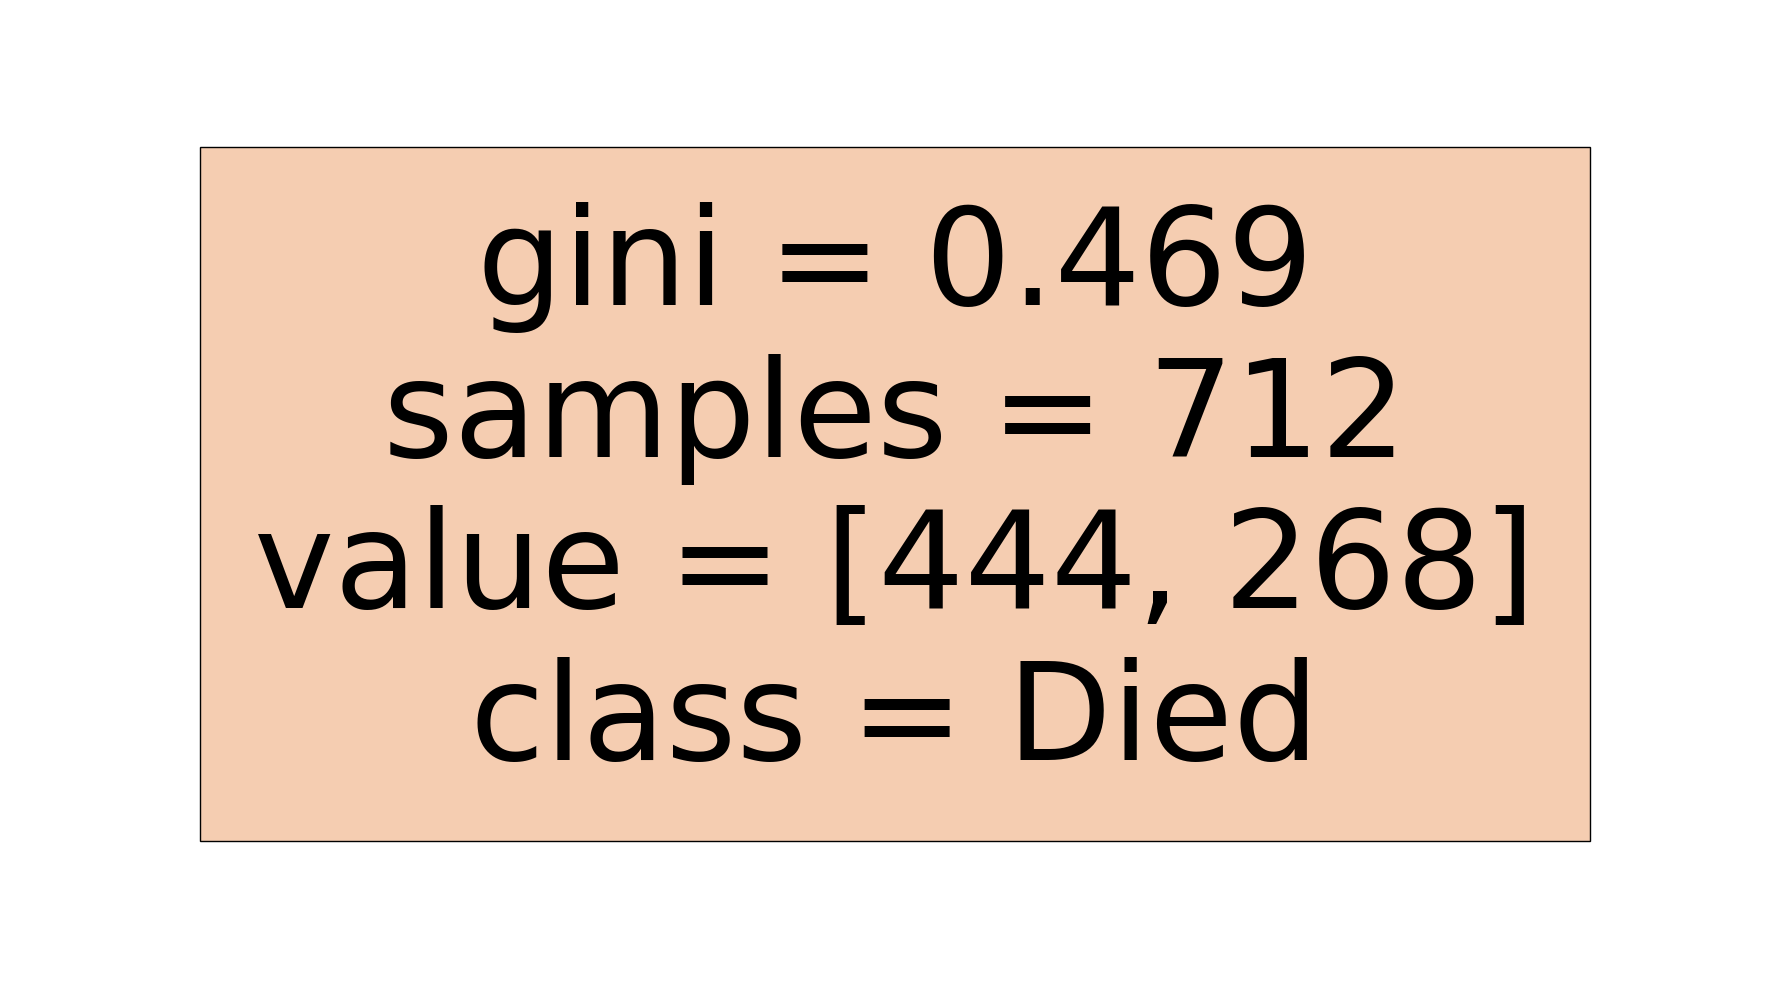

In [26]:
# plt.figure(figsize=(18,10))
# plot_tree(
#     model,
#     feature_names=x.columns,
#     class_names=["Died","Survived"],
#     filled=True
# )

# plt.tight_layout()
# plt.show()

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["Died","Survived"],
    filled = True,
    max_depth=2
)
plt.tight_layout()
plt.show()